# Power Rabi (state, error amplification)

In [33]:
from pathlib import Path

import numpy as np

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal16_power_rabi_state import PowerRabiState

## Run parameters

Requires a prior `run13_iq_blob.ipynb` run (or explicit `ROTATION_DEGREES`/`THRESHOLD` below) so
`analysis()` can discriminate each shot into |0>/|1>.

In [34]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "power_rabi_state"

QUBITS = ["q1"]
OPERATION = "x180"  # "x180", "x90", "-x90", "y90", or "-y90"
# Multiplicative scale factors applied to the qubit's current rxy.amp180 -- not absolute
# amplitudes. Keep this narrow (a few % around 1.0) for error amplification; widen it to
# ~[0, 2] instead if MAX_NUMBER_OF_PULSES below is set to 1 for a plain oscillation fit.
AMPLITUDE_FACTORS = np.arange(start=0.8, stop=1.2, step=0.004)
# Number of repeated pulses per shot is swept up to (not including) this value -- odd counts
# 1,3,5,... for "x180", or counts of 2,6,10,... for the x90-family operations. Kept far below
# the QM reference's default of 200: each N unrolls N literal pulses into the compiled
# schedule (see cal16_power_rabi_state.py's module docstring), so a large value here makes
# for a very large schedule.
MAX_NUMBER_OF_PULSES = 80
REPETITIONS = 200  # Single shots averaged into a population fraction per (N, amplitude) point
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)

# None: use each qubit's own measure.acq_rotation/acq_threshold (set by run13_iq_blob.ipynb)
ROTATION_DEGREES = None
THRESHOLD = None

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None to skip persistence

## Hardware and experiment

In [35]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = PowerRabiState(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [36]:
dataset = experiment.run_measurement(
    operation=OPERATION,
    amplitude_factors=AMPLITUDE_FACTORS,
    max_number_of_pulses=MAX_NUMBER_OF_PULSES,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

<xarray.Dataset> Size: 38MB
Dimensions:              (acq_index_S21_q1: 800000)
Coordinates:
    amplitude_factor_q1  (acq_index_S21_q1) float64 6MB 0.8 0.804 ... 1.196
    rep_q1               (acq_index_S21_q1) float64 6MB 0.0 0.0 ... 199.0 199.0
    n_pi_q1              (acq_index_S21_q1) int64 6MB 1 1 1 1 1 ... 79 79 79 79
  * acq_index_S21_q1     (acq_index_S21_q1) int64 6MB 0 1 2 ... 799998 799999
Data variables:
    S21_q1               (acq_index_S21_q1) complex128 13MB (-0.0008733526468...
Attributes:
    tuid:     20260915-153547-434-d276e1

## Optional: Simulated data

In [37]:
# dataset = experiment.simulated_data(
#     operation=OPERATION,
#     amplitude_factors=AMPLITUDE_FACTORS,
#     max_number_of_pulses=MAX_NUMBER_OF_PULSES,
#     repetitions=REPETITIONS,
#     true_amplitude_factor=1.03,
#     assignment_fidelity=0.98,
#     noise=0.03,
#     seed=42,
# )

## Analysis

In [38]:
results = experiment.analysis(rotation_degrees=ROTATION_DEGREES, threshold=THRESHOLD)
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: [{result.selection_method}] "
            f"pi_pulse_amplitude={result.pi_pulse_amplitude:.6f}"
        )
    else:
        print(f"{qubit}: fit failed")

q1: [error_amplification] pi_pulse_amplitude=0.654568


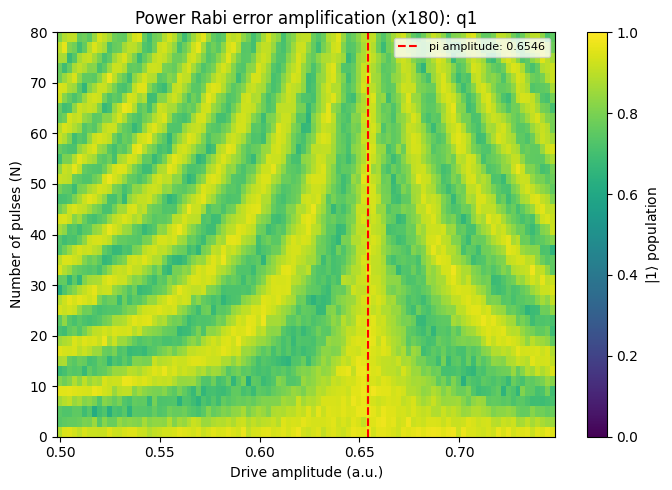

In [39]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [40]:
if SAVE_FITTED_DEVICE is not None:
    updated_qubits = experiment.update_device()
    if not updated_qubits:
        raise ValueError("No qubit has a successful fit -- nothing to save.")
    for qubit_name in updated_qubits:
        qubit = hardware_agent.quantum_device.get_element(qubit_name)
        print(f"{qubit_name}: rxy.amp180 updated to {qubit.rxy.amp180:.6f}")
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

q1: rxy.amp180 updated to 0.654568
Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [41]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()